# Mean-centred time-frequency analysis

This tutorial shows the visualization options for time-frequency analysis.

## Loading data

First we will load the raw data and extract epochs.

In [37]:
import numpy as np
import mne
from mne.datasets import sample
from mne.stats import permutation_cluster_test

data_path = sample.data_path()
meg_path = data_path / "MEG" / "sample"
raw_fname = meg_path / "sample_audvis_filt-0-40_raw.fif"

raw = mne.io.read_raw_fif(raw_fname)
events = mne.find_events(raw, stim_channel="STI 014")

# Extract epochs
epochs = mne.Epochs(
    raw,
    events,
    event_id={
        "auditory left": 1,
        "auditory right": 2,
        "visual left": 3,
        "visual right": 4
    },
    tmin=-1, tmax=2,
    picks=['eeg'],
    baseline=(None, 0),
    preload=True,
    verbose=False
)
epochs = epochs.resample(100)

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


## Running time-frequency decomposition

Next, we will perform a time-frequency decomposition via Morlet wavelets.

In [46]:
tfr = epochs.compute_tfr(
    method="morlet",
    freqs=np.exp(np.linspace(np.log(7), np.log(30), 10)), # log space freqs
    n_cycles=5,
    decim=5,
    return_itc=False,
    average=False)
tfr = tfr.crop(tmin=-0.2, tmax=0.8)
tfr.data = 10*np.log10(tfr.data)
tfr = tfr.apply_baseline(mode="mean", baseline=(None, 0))

Applying baseline correction (mode: mean)


## Fitting and evaluating mean-centred PLS model

Next, we will fit a mean-centred PLS model comparing the auditory vs visual and left vs right trials.

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: ylabel='Brain score'>,
        <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>], dtype=object))

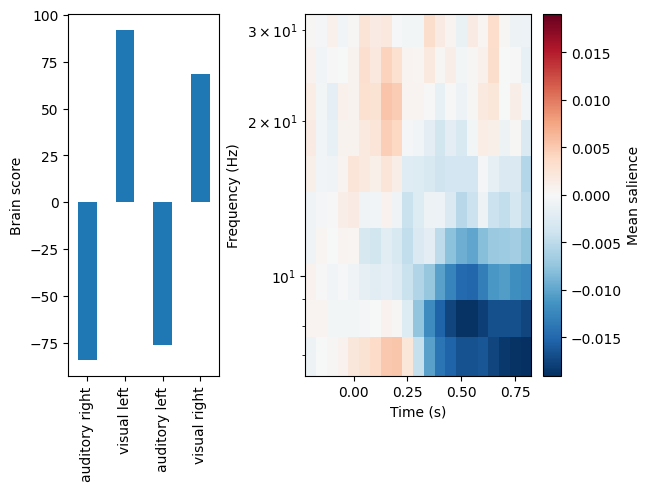

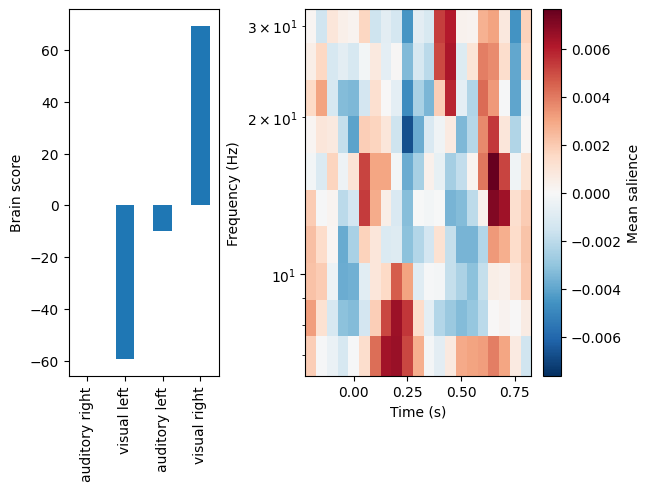

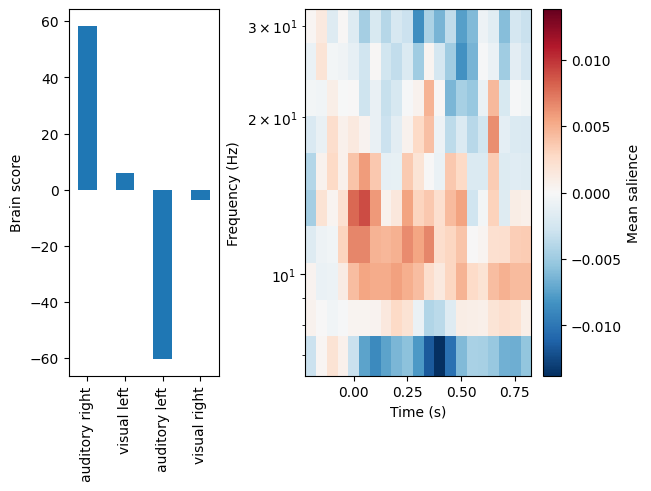

In [60]:
import mne_plsc
import pandas as pd

labels = mne_plsc.utils.get_epoch_labels(tfr)
labels = pd.Categorical(labels, categories=['auditory left', 'auditory right', 'visual left', 'visual right']) # Re-order for plotting
res = mne_plsc.fit_mc(tfr,
                      between=labels,
                      random_state=123)
res.plot_lv(0)
res.plot_lv(1)
res.plot_lv(2)

As we can see, the patterns in the data saliences differentiate first between the auditory vs visual stimuli, then between the left vs right visual stimuli, then between the left vs right auditory stimuli. We can assess their significance via permutation testing. We will do 100 permutations here for speed, but it would be advisable to do many more for a real analysis.

In [51]:
res.permute(100)
print(res.summary())

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 31.77it/s]

   LV index  singular value  variance explained   p value
0         0      160.938154            0.624732  0.009901
1         1       91.909034            0.203747  0.029703
2         2       84.327719            0.171521  0.019802
3         3        0.000000            0.000000       NaN


## Cluster analysis

Next we can perform bootstrap resampling to estimate the $z$ scores of the brain saliences to cluster reliable saliences. For simplicity, we'll focus on the first latent variable pair.

In [61]:
res.bootstrap(100)
res.add_adjacency()
res.cluster(threshold=3)

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.25it/s]

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.


-- number of adjacent vertices : 59
Clustering z-scores
Computing clusters for lv_idx 0...
37 clusters
Computing clusters for lv_idx 1...
30 clusters
Computing clusters for lv_idx 2...
33 clusters


This yields many clusters, but as we can see, almost all of the reliable saliences are part of a single main cluster:

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

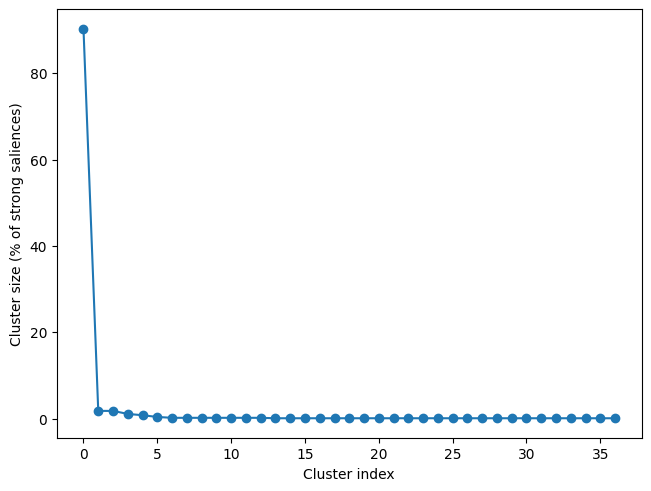

In [62]:
res.plot_cluster_sizes(lv_idx=0)

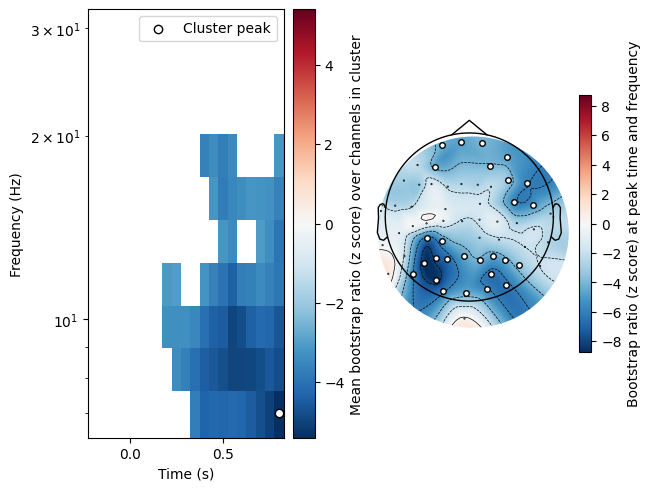

In [63]:
res.plot_cluster(lv_idx=0, cluster_idx=0)